# The idea
In Solar Jet Hunter, we provided data corresponding to "CJ" events in the HEK database. The volunteers reported if they found jets in the data, or not. While the catalogue contains the resulting jets, it means that we also have access to all the data that has been looked at by the volunteers and that did not contain any jet. This notebook describes how to retrieve this data in the idea that it can be useful as a "negative" part of a training set to be use for machine learning.

In [20]:
import numpy as np
from utils.Jet_class_light import json_import_list

import os

import matplotlib.pyplot as plt

import astropy.units as u
from astropy.coordinates import SkyCoord
from astropy.time import Time
from astropy.visualization import ImageNormalize, SqrtStretch

import sunpy.coordinates  # NOQA
import sunpy.map
from sunpy.net import Fido
from sunpy.net import attrs as a

In [41]:
jsoc_email = "your_email_here"  ### for more details check the notebook about downloading cutouts

# Open catalog
See tutorial for more details

In [2]:
json_file = 'exports/Jet_clusters_3.0_2.0.paperID.json'
Jet_catalogue=json_import_list(json_file)

The 883 JetCluster objects are imported from exports/Jet_clusters_3.0_2.0.paperID.json.


Extract the "HEK event" names (i.e. "SOL") for each jet in the catalogue

In [13]:
Cluster_SOL = np.array([Jet_catalogue[i].SOL for i in range(len(Jet_catalogue))], dtype=str)
print(len(Cluster_SOL))

883


Some jets were found in the same HEK events, so that list contains duplicate. Let's make a list of unique SOL event ids

In [14]:
unique_SOL_events = np.unique(Cluster_SOL)
print(len(unique_SOL_events))

229


# Get the original events from the HEK database
Note that since we are looking for reports in several years, this will take a few seconds

In [3]:
from sunpy.net import attrs as a, Fido
timerange = a.Time('2011/01/01 00:00:00', '2017/01/01 00:00:00')
res = Fido.search(timerange, a.hek.CJ) 

C:\Users\mussesm1.SDSCI\AppData\Local\miniconda3\envs\sunpyenv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
print(len(res[0]))

1863


# Example with one HEK event
The following demonstrate how to define and download the data from one HEK event. This should be adapted in a script to loop over all HEK events found above. We start with the first event that we read from the jet catalogue.

In [18]:
selection0 = res['hek'][res['hek']["SOL_standard"]==unique_SOL_events[0]]
selection0

gs_thumburl,comment_count,hpc_bbox,outflow_width,frm_humanflag,hgc_coord,event_coordsys,obs_levelnum,hpc_coord,event_npixels,gs_imageurl,ar_polarity,frm_paramset,hrc_coord,event_starttime,ar_mtwilsoncls,event_type,intensmin,obs_meanwavel,outflow_openingangle,frm_url,skel_chaincode,bound_chaincode,noposition,active,intensmax,frm_versionnumber,area_uncert,obs_dataprepurl,hpc_geom,hgc_bbox,intensmedian,chaincodetype,obs_channelid,event_clippedspatial,ar_noaaclass,SOL_standard,event_avg_rating,eventtype,intensunit,hpc_boundcc,event_mapurl,frm_contact,ar_penumbracls,intensmean,bound_ccstartc1,outflow_transspeed,frm_name,area_atdiskcenter,frm_identifier,obs_observatory,event_description,boundbox_c2ur,obs_firstprocessingdate,boundbox_c2ll,frm_institute,hrc_bbox,refs_orig,ar_mcintoshcls,event_maskurl,bound_ccstartc2,gs_movieurl,event_score,skel_startc2,skel_startc1,event_expires,outflow_speedunit,hrc_boundcc,event_probability,intensvar,frm_daterun,outflow_lengthunit,outflow_length,event_coordunit,hpc_y,hpc_x,search_instrument,ar_numspots,kb_archivdate,kb_archivist,intenstotal,sum_overlap_scores,hgs_boundcc,intensskew,obs_includesnrt,rasterscan,obs_wavelunit,kb_archivid,search_frm_name,boundbox_c1ur,ar_noaanum,area_atdiskcenteruncert,boundbox_c1ll,event_importance_num_ratings,ar_compactnesscls,skel_curvature,event_testflag,event_c2error,hrc_r,skel_nsteps,hgs_y,obs_title,hgs_x,hcr_checked,frm_specificid,event_title,obs_instrument,event_c1error,revision,hpc_radius,outflow_widthunit,event_endtime,event_importance,event_coord2,event_coord3,event_coord1,search_observatory,area_raw,concept,solar_object_locator,event_pixelunit,hgc_boundcc,outflow_speed,hgc_x,hrc_a,event_peaktime,hgc_y,gs_galleryid,hgs_coord,ar_zurichcls,bound_ccnsteps,intenskurt,event_clippedtemporal,rasterscantype,search_channelid,hgs_bbox,area_unit,obs_lastprocessingdate,refs
str194,str1,str133,object,str5,str35,str12,object,str42,object,str188,object,str14,str41,Time,str1,str2,object,float64,object,str61,str1,str1,str5,str4,object,object,object,str1,str186,str125,object,str1,str8,str1,str1,str30,object,str2,str1,str1,str1,str12,str1,object,object,object,str22,object,str29,str4,str560,float64,str1,float64,str23,str110,str1,str1,str1,object,str252,str1,object,object,str1,str6,str1,object,object,str19,str2,object,str6,float64,float64,str7,object,str19,str19,object,str22,str1,object,str1,str1,str2,str82,str16,float64,object,object,float64,str1,str1,object,str5,float64,float64,object,float64,str1,float64,str5,str1,str68,str7,float64,str1,str19,str2,Time,object,float64,object,float64,str4,object,str11,str30,str1,str1,object,float64,float64,object,float64,str48,str32,str1,object,object,str1,str1,str16,str120,str1,str1,object
http://www.lmsal.com/hpkb/podimages/2011/01/21/pod_sainz%2Bdalda_alberto_2011-01-21T22%3A42%3A32.088/thumb/panorama_asainz_AIA-304_AIA-211_20110120T094545_at_20110121T224035.jpg,0,"POLYGON((-335 -1119,-155 -1119,-155 -887,-335 -887,-335 -1119))",None,true,POINT(-71.12168289 -75.492392),UTC-HPC-TOPO,None,POINT(-245 -1003),None,http://www.lmsal.com/hpkb/podimages/2011/01/21/pod_sainz%2Bdalda_alberto_2011-01-21T22%3A42%3A32.088/panorama_asainz_AIA-304_AIA-211_20110120T094545_at_20110121T224035.jpg,None,n/a,POINT(1.05939829132651 166.273314931505),2011-01-20 09:00:09.000,,CJ,None,2.11e-06,None,n/a,,,false,true,None,None,None,,010300000001000000050000000000000000F074C000000000007C91C000000000006063C000000000007C91C000000000006063C00000000000B88BC00000000000F074C00000000000B88BC00000000000F074C000000000007C91C0,"POLYGON((-74.395154 -72.691952,-58.959908 -80.8028,-27.277949 -69.861778,-65.488232 -67.863333,-74.395154 -72.691952))",None,,211,,,SOL2011-01-20T09:00:09L289C165,None,14,,,,Scott Green,,None,None,None,asainz,None,Annotator-build_20100909-avc,SDO,Coronal jet in the South pole. It seems like a twisted loop. High temporal resolution.,-1119.0,,-887.0,LMSAL,"POLYGON((1.198512 163.333644,1.159126 172.113769,0.923909 170.087857,0.972864 159.309574,1.198512 163.33

As you can see, a unique id in the HEK catalogue can corresponds to several entries. This is because the jet has been reported in more than one passband of AIA, or sometimes, even by different instruments (e.g. AIA and IRIS). However, the spatial and time informations for this event are the same in all entries. Therefore, we will keep only the first line here.

## Get FOV for that event

Let's extract the coordinates of the FOV of this event, which correspond to the field of view that has been shown to volunteers.


In [19]:
fov0 = selection0['hpc_bbox'] ## stands for helioprojective coordinates of the bounding box
x1 = float(fov0.value[0].strip('POLYGON()').split(',')[0].split()[0])
x2 = float(fov0.value[0].strip('POLYGON()').split(',')[1].split()[0])
y1 = float(fov0.value[0].strip('POLYGON()').split(',')[0].split()[1])
y2 = float(fov0.value[0].strip('POLYGON()').split(',')[2].split()[1])

## Get AIA cutouts for that event

Now we will download the images corresponding to this time and fov using this example https://docs.sunpy.org/en/stable/generated/gallery/acquiring_data/downloading_cutouts.html#sphx-glr-generated-gallery-acquiring-data-downloading-cutouts-py

In [22]:
start_time = selection0['event_starttime'][0]
end_time = selection0['event_endtime'][0]
bottom_left = SkyCoord(x1*u.arcsec, y1*u.arcsec, obstime=start_time, observer="earth", frame="helioprojective")
top_right = SkyCoord(x2*u.arcsec, y2*u.arcsec, obstime=start_time, observer="earth", frame="helioprojective")
#print(bottom_left)
#print(top_right)

In [23]:
cutout = a.jsoc.Cutout(bottom_left, top_right=top_right, tracking=False)

In [25]:
query = Fido.search(
    a.Time(start_time, end_time),
    a.Wavelength(304*u.angstrom),
    a.Sample(24*u.s),
    a.jsoc.Series.aia_lev1_euv_12s,
    a.jsoc.Notify(jsoc_email),
    a.jsoc.Segment.image,
    cutout,
)
print(query)

Results from 1 Provider:

149 Results from the JSOCClient:
Source: http://jsoc.stanford.edu

       T_REC         TELESCOP INSTRUME WAVELNTH CAR_ROT
-------------------- -------- -------- -------- -------
2011-01-20T09:00:02Z  SDO/AIA    AIA_4      304    2105
2011-01-20T09:00:26Z  SDO/AIA    AIA_4      304    2105
2011-01-20T09:00:50Z  SDO/AIA    AIA_4      304    2105
2011-01-20T09:01:14Z  SDO/AIA    AIA_4      304    2105
2011-01-20T09:01:38Z  SDO/AIA    AIA_4      304    2105
2011-01-20T09:02:02Z  SDO/AIA    AIA_4      304    2105
2011-01-20T09:02:26Z  SDO/AIA    AIA_4      304    2105
2011-01-20T09:02:50Z  SDO/AIA    AIA_4      304    2105
2011-01-20T09:03:14Z  SDO/AIA    AIA_4      304    2105
2011-01-20T09:03:38Z  SDO/AIA    AIA_4      304    2105
2011-01-20T09:04:02Z  SDO/AIA    AIA_4      304    2105
2011-01-20T09:04:26Z  SDO/AIA    AIA_4      304    2105
2011-01-20T09:04:50Z  SDO/AIA    AIA_4      304    2105
                 ...      ...      ...      ...     ...
2011-01-20T

Let's go ahead an download (will take seconds to minutes)

In [26]:
files = Fido.fetch(query, overwrite=True)
files.sort()

2025-04-14 15:58:19 - drms - INFO: Export request pending. [id=JSOC_20250414_008692, status=2]
2025-04-14 15:58:19 - drms - INFO: Waiting for 0 seconds...
2025-04-14 15:58:19 - drms - INFO: Export request pending. [id=JSOC_20250414_008692, status=1]
2025-04-14 15:58:19 - drms - INFO: Waiting for 5 seconds...
2025-04-14 15:58:25 - drms - INFO: Export request pending. [id=JSOC_20250414_008692, status=1]
2025-04-14 15:58:25 - drms - INFO: Waiting for 5 seconds...
2025-04-14 15:58:30 - drms - INFO: Export request pending. [id=JSOC_20250414_008692, status=1]
2025-04-14 15:58:30 - drms - INFO: Waiting for 5 seconds...
2025-04-14 15:58:36 - drms - INFO: Export request pending. [id=JSOC_20250414_008692, status=1]
2025-04-14 15:58:36 - drms - INFO: Waiting for 5 seconds...
2025-04-14 15:58:41 - drms - INFO: Export request pending. [id=JSOC_20250414_008692, status=1]
2025-04-14 15:58:41 - drms - INFO: Waiting for 5 seconds...
2025-04-14 15:58:47 - drms - INFO: Export request pending. [id=JSOC_20

INFO: 149 URLs found for download. Full request totaling 13MB [sunpy.net.jsoc.jsoc]


Files Downloaded:   0%|                                                                      | 0/149 [00:00<?, ?file/s]
aia.lev1_euv_12s.2011-01-20T090002Z.304.image.fits:   0%|                                  | 0.00/89.3k [00:00<?, ?B/s]
aia.lev1_euv_12s.2011-01-20T090002Z.304.image.fits:   1%|▎                        | 1.02k/89.3k [00:00<00:46, 1.90kB/s]
Files Downloaded:   1%|▍                                                             | 1/149 [00:01<03:05,  1.25s/file]
aia.lev1_euv_12s.2011-01-20T090026Z.304.image.fits:   0%|                                  | 0.00/89.3k [00:00<?, ?B/s]
aia.lev1_euv_12s.2011-01-20T090026Z.304.image.fits:   1%|▎                        | 1.02k/89.3k [00:00<00:40, 2.16kB/s]
Files Downloaded:   1%|▊                                                             | 2/149 [00:02<02:26,  1.01file/s]
aia.lev1_euv_12s.2011-01-20T090050Z.304.image.fits:   0%|                                  | 0.00/89.3k [00:00<?, ?B/s]
aia.lev1_euv_12s.2011-01-20T090050Z.304.

## Plot the data
There is no need to do this right away but in the end it is expected that the data will be saved in an image format. Here are the ways to plot the data.

Load in a sunpy map sequence

In [27]:
sequence = sunpy.map.Map(files, sequence=True)

### Plot without axes or anotation
For machine learning, we should not have anything more than data (no grid, axis, title). This looks like:

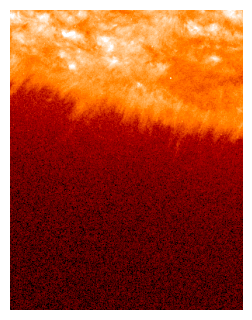

In [29]:
smap = sequence[0] ## let's plot the first map in the sequence

figure = plt.figure(frameon=False, figsize=(3,3))
ax = plt.axes([0, 0, 1, 1])
# Disable the axis
ax.set_axis_off()

# Plot the map.
# Since we are not interested in the exact map coordinates,
# we can simply use :meth:`~matplotlib.Axes.imshow`.
norm = smap.plot_settings['norm']
norm.vmin, norm.vmax = np.percentile(smap.data, [1, 99.9])
ax.imshow(smap.data,
          norm=norm,
          cmap=smap.plot_settings['cmap'],
          origin="lower")
plt.show()

### Plot (the usual way)
For reference, this is the kind of image that was shown to volunteers:

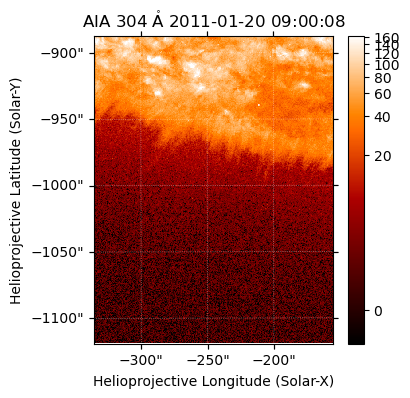

In [31]:
smap = sequence[0]

fig = plt.figure(figsize=(4,4))
ax = fig.add_subplot(projection=smap)
smap.plot(axes=ax)
plt.colorbar()

plt.show()

## Which part(s) of this event contained jet(s)?
So far, what we have been doing is downloading all the data from a HEK event, for which we have at least one jet in the catalogue. So part of the data in the map sequence contains a least one jet. Keep in mind that multiple jets in the SJH catalogue can belong to this HEK event.

Let's initiate an array that will contain the value True or False for the question "contains a jet"

In [32]:
contain_jet = np.zeros(len(sequence), dtype=bool) # for the moment initialized with only '0' everywhere

Let's create an array with the time stamp of each map

In [33]:
dates = [mmap.date for mmap in sequence]

Let's extract all the jets from the SJH catalogue that belong to that HEK event

In [36]:
sjh_identifier = np.array([Jet_catalogue[i].ID for i in range(len(Jet_catalogue))], dtype=str)
sjh_identifier[Cluster_SOL == unique_SOL_events[0]]

array(['sjh_2011-01-20T09_1'], dtype='<U19')

In this case there is only one jet in this SOL event, but in other cases there will be several, so we will loop anyway

In [39]:
# date: Observation time of the start of the jet (format YYYY-MM-DDThh:mm:ss)
Cluster_date = np.array([Jet_catalogue[i].obs_time for i in range(len(Jet_catalogue))], dtype='datetime64')
# duration of the jet (minutes)
stat_dur = np.array([Jet_catalogue[i].Duration for i in range(len(Jet_catalogue))], dtype=float)

In [40]:
jets = sjh_identifier[Cluster_SOL == unique_SOL_events[0]]
for jet in jets:
    start_jet = Cluster_date[sjh_identifier == jet][0]
    duration_jet = stat_dur[sjh_identifier == jet][0] ## in minutes
    end_jet = start_jet + np.timedelta64(int(duration_jet*60),'s')
#    print(start_jet)
#    print(end_jet)
    contain_jet = ((dates >= start_jet)&(dates <= end_jet))|contain_jet
print(contain_jet)

[False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True False]


This seems to do what I want but one will need to carefully check. Please open an issue on GitHub if you find anything that's not done properly